# **06. Auto-Encoder**

> 이번 실습에서는 Auto-Encoder를 직접 구현하는 실습을 진행해보자.
>
>Auto-Encoder는 bottleneck layer를 통해 데이터에서 필요한 정보만 압축한 code(representation)을 학습하도록 하는 뉴럴넷 구조이다.
>
>Auto-Encoder의 output은 input을 reconstruction 하도록 학습되어 별도의 데이터 라벨이 필요 없는 unsupervised learning 방식으로 학습된다.
>
>Dimensionality reduction, Image Denoising, Anomaly Detection 등 다양한 Task에서 활용할 수 있다.


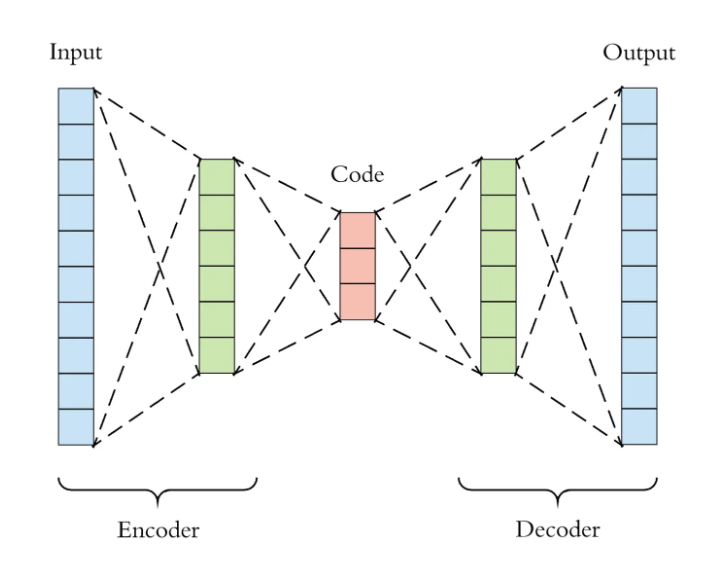

## 1. Import Packages

> 필요한 package를 import한다.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.datasets as datasets
from torchvision import transforms

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

## 2.Auto-Encoder

> Fashion MNIST 데이터셋을 재생성하는 Auto-Encoder를 직접 구현하고, 성능을 확인해보도록 하자.

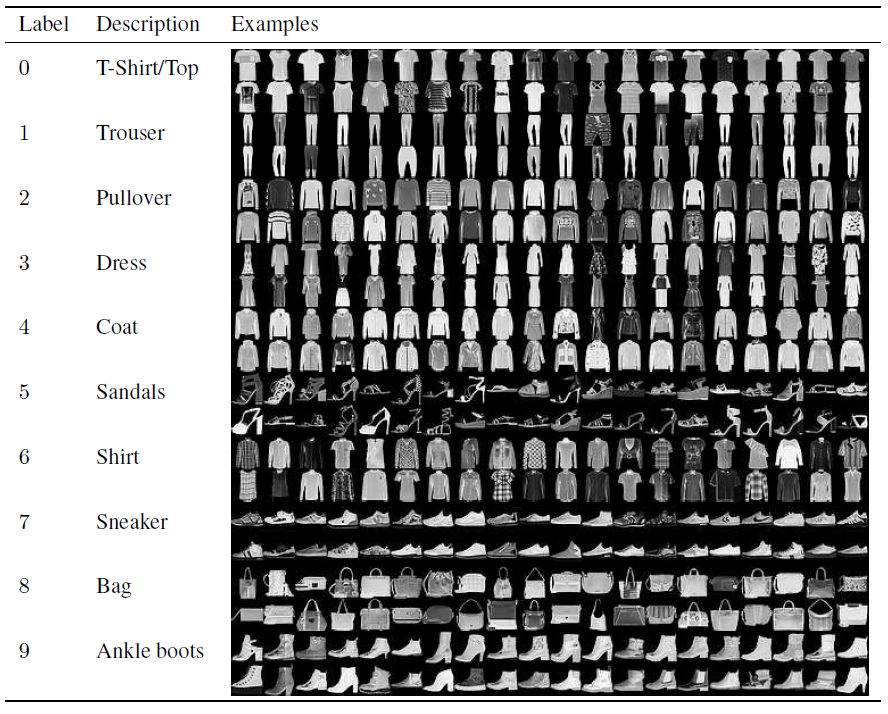

In [2]:
# Hyper-parameters
device = 'cuda' if torch.cuda.is_available() else 'cpu'
lr = 0.001
batch_size = 128

In [3]:
transform = transforms.ToTensor()

trainset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=1)

testset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=False, num_workers=1)

100%|██████████| 26.4M/26.4M [00:00<00:00, 113MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.37MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 55.5MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.9MB/s]


In [4]:
batch = next(iter(trainloader))

print(batch[0].shape)
print(batch[1].shape)

torch.Size([128, 1, 28, 28])
torch.Size([128])


>Fully Connected Layer를 이용한 간단한 Auto-Encoder를 구현한다.

In [5]:
class Autoencoder(nn.Module):
    """
    MLP 기반의 Autoencoder

    입력 이미지를 Encoder를 통해 저차원의 latent vector로 압축한 뒤,
    Decoder를 통해 다시 원본 이미지 크기로 복원
    """

    def __init__(self, latent_dim=64):
        super(Autoencoder, self).__init__()

        # 압축된 latent vector의 차원
        self.latent_dim = latent_dim

        # Encoder
        # 입력 이미지 [128, 1, 28, 28]을 [128, 784]로 펼친 뒤 입력
        #
        # [128, 784] → [128, 64]
        # 784차원의 이미지 데이터를 latent_dim(기본값 64) 차원으로 압축
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, latent_dim),
            nn.ReLU(),
        )

        # Decoder
        # Encoder에서 생성된 latent vector를 다시 원본 이미지 차원으로 복원
        #
        # [128, 64] → [128, 784]
        # Sigmoid를 적용하여 각 출력값을 0~1 범위로 제한
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 784),
            nn.Sigmoid(),
        )

    def forward(self, x):

        # 입력 이미지의 shape: [128, 1, 28, 28]
        #
        # Linear Layer에 입력하기 위해 각 28 × 28 이미지를
        # 784차원의 1차원 벡터로 펼침
        #
        # [128, 1, 28, 28] → [128, 784]
        x = x.reshape(-1, 28 * 28)

        # Encoder를 통해 입력 이미지를 latent vector로 압축
        #
        # [128, 784] → [128, 64]
        # latent_dim=64인 경우 각 이미지를 64차원으로 표현
        encoded = self.encoder(x)

        # Decoder를 통해 latent vector를 원본 이미지 차원으로 복원
        #
        # [128, 64] → [128, 784]
        decoded = self.decoder(encoded)

        # 펼쳐져 있는 784차원의 복원 이미지를
        # 원래 이미지 형태로 변환
        #
        # [128, 784] → [128, 1, 28, 28]
        decoded = decoded.reshape(-1, 1, 28, 28)

        # 복원된 이미지 반환
        return decoded

In [6]:
autoencoder = Autoencoder(latent_dim=64).to(device)

> Auto-Encoder는 Input으로 넣은 이미지를 그대로 재생성(reconstruction)하는 방식으로 학습한다.
>
>구체적으로는 Input 이미지와 Output 이미지 사이의 MSE Loss를 계산하여 학습한다.

In [7]:
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=lr)

def train_autoencoder(net, optimizer, trainloader, epochs=10):

  loss_list = []
  steps = []
  step = 0
  for epoch in range(epochs):

    running_loss = 0.0
    for i, data in enumerate(trainloader):
      inputs, _ = data
      inputs = inputs.to(device)

      optimizer.zero_grad()

      outputs = net(inputs)
      loss = criterion(outputs, inputs) # MSE Loss (reconstruction)
      loss.backward()
      optimizer.step()

      running_loss += loss.item()
      loss_list.append(loss.item())
      steps.append(step)
      step += 1
      if (i+1) % 100 == 0:
          print('[%d, %5d] loss: %.3f' %
                (epoch + 1, i + 1, running_loss / 100))
          running_loss = 0.0

  plt.plot(steps, loss_list)
  print('Finished Training')

[1,   100] loss: 0.079
[1,   200] loss: 0.041
[1,   300] loss: 0.032
[1,   400] loss: 0.028
[2,   100] loss: 0.023
[2,   200] loss: 0.021
[2,   300] loss: 0.020
[2,   400] loss: 0.018
[3,   100] loss: 0.017
[3,   200] loss: 0.016
[3,   300] loss: 0.015
[3,   400] loss: 0.015
[4,   100] loss: 0.014
[4,   200] loss: 0.014
[4,   300] loss: 0.013
[4,   400] loss: 0.013
[5,   100] loss: 0.013
[5,   200] loss: 0.013
[5,   300] loss: 0.012
[5,   400] loss: 0.012
[6,   100] loss: 0.012
[6,   200] loss: 0.012
[6,   300] loss: 0.012
[6,   400] loss: 0.012
[7,   100] loss: 0.012
[7,   200] loss: 0.012
[7,   300] loss: 0.012
[7,   400] loss: 0.012
[8,   100] loss: 0.011
[8,   200] loss: 0.011
[8,   300] loss: 0.011
[8,   400] loss: 0.011
[9,   100] loss: 0.011
[9,   200] loss: 0.011
[9,   300] loss: 0.011
[9,   400] loss: 0.011
[10,   100] loss: 0.011
[10,   200] loss: 0.011
[10,   300] loss: 0.011
[10,   400] loss: 0.011
Finished Training


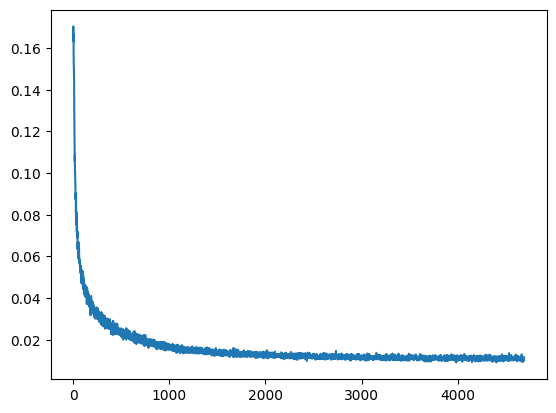

In [8]:
train_autoencoder(autoencoder, optimizer, trainloader)

> 학습한 Auto-Encoder가 테스트 이미지들에 대해서 재생성을 얼마나 잘해내는 지 시각화해보자.

In [9]:
def test_autoencoder(net, testloader, n=10):
  net.eval()

  input_imgs = []
  recon_imgs = []

  with torch.no_grad():
    for i, (inputs, _) in enumerate(testloader):
      inputs = inputs.to(device)
      outputs = net(inputs)

      input_imgs.append(inputs.detach().cpu().numpy())
      recon_imgs.append(outputs.detach().cpu().numpy())

      # 결과 확인을 위해 이미지 10개 생성
      if i == n:
        break


  # Auto-encoder를 이용하여 재생성한 이미지를 시각화
  plt.figure(figsize=(2*n, 4))
  for i in range(n):
    # original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(input_imgs[i].squeeze())
    plt.title("original")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(recon_imgs[i].squeeze())
    plt.title("reconstructed")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
  plt.show()
  plt.close()

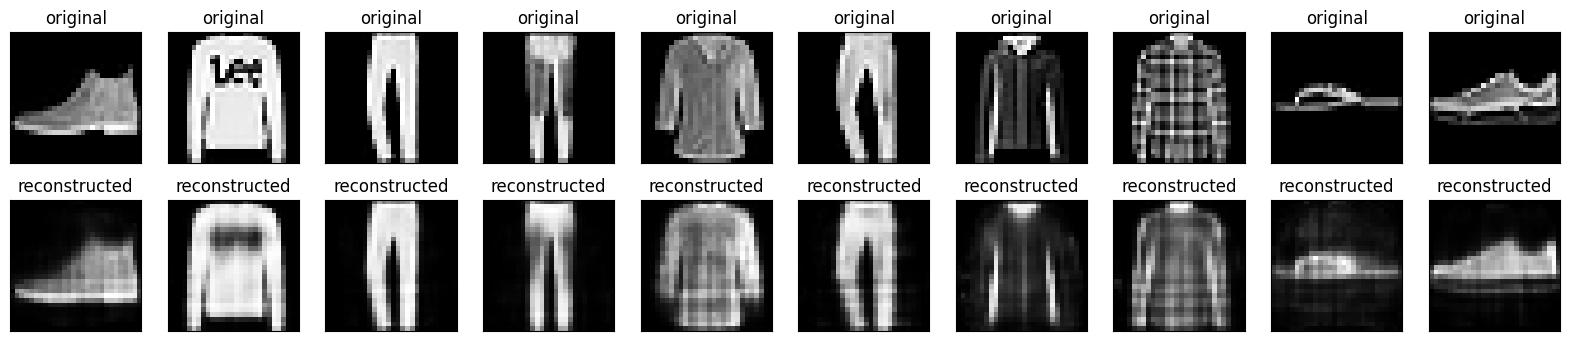

In [10]:
test_autoencoder(autoencoder, testloader)

## 3. Denoising Auto-Encoder

> 이번에는 Auto-Encoder를 이용하여 이미지에 Noise가 있을 때, 이를 제거해주는 Denoising Auto-Encoder를 구현해보도록 한다.
>
>앞서 구현한 Auto-Encoder와는 다르게 Fully Connected Layer 대신 Convolution layer를 활용한다.



In [11]:
class Denoise_Autoencoder(nn.Module):
    """
    Convolution 기반의 Denoising Autoencoder

    Noise가 포함된 이미지를 Encoder에 입력하여 특징을 압축하고,
    Decoder를 통해 Noise가 제거된 원본 이미지를 복원
    """

    def __init__(self):
        super(Denoise_Autoencoder, self).__init__()

        # Encoder
        # Convolution을 통해 이미지의 공간 크기(H, W)는 줄이고,
        # channel 수는 증가시키면서 이미지의 특징을 추출
        self.encoder = nn.Sequential(

            # [128, 1, 28, 28] → [128, 16, 14, 14]
            # stride=2이므로 이미지의 가로/세로 크기가 절반으로 감소
            nn.Conv2d(
                1, 16,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            # [128, 16, 14, 14] → [128, 8, 7, 7]
            # 다시 가로/세로 크기를 절반으로 줄여
            # 압축된 latent representation을 생성
            nn.Conv2d(
                16, 8,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.ReLU(),
        )

        # Decoder
        # ConvTranspose2d를 사용하여 압축된 특징의
        # 공간 크기(H, W)를 다시 증가시켜 원본 이미지를 복원
        self.decoder = nn.Sequential(

            # [128, 8, 7, 7] → [128, 8, 14, 14]
            # stride=2와 output_padding=1을 사용하여
            # 가로/세로 크기를 2배로 증가
            nn.ConvTranspose2d(
                8, 8,
                kernel_size=3,
                output_padding=1,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            # [128, 8, 14, 14] → [128, 16, 28, 28]
            # 다시 가로/세로 크기를 2배로 증가시켜
            # 원본 이미지의 공간 크기인 28 × 28로 복원
            nn.ConvTranspose2d(
                8, 16,
                kernel_size=3,
                output_padding=1,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            # [128, 16, 28, 28] → [128, 1, 28, 28]
            # channel을 16 → 1로 변환하여
            # 원본 MNIST와 동일한 흑백 이미지 형태로 복원
            nn.Conv2d(
                16, 1,
                kernel_size=3,
                stride=1,
                padding=1
            ),

            # 복원된 이미지의 각 픽셀값을 0~1 범위로 제한
            nn.Sigmoid()
        )

    def forward(self, x):

        # Noise가 포함된 입력 이미지
        # x의 shape: [128, 1, 28, 28]

        # Encoder를 통해 이미지의 특징을 압축
        # [128, 1, 28, 28] → [128, 8, 7, 7]
        encoded = self.encoder(x)

        # Decoder를 통해 압축된 특징으로부터 이미지를 복원
        # [128, 8, 7, 7] → [128, 1, 28, 28]
        decoded = self.decoder(encoded)

        # Noise가 제거된 복원 이미지 반환
        return decoded

In [12]:
autoencoder = Denoise_Autoencoder().to(device)

> Denoising Auto-Encoder 학습을 위해 input 이미지에 noise를 더해주는 코드를 추가합니다.

In [13]:
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=lr)

def train_autoencoder(net, optimizer, trainloader, epochs=5):
  loss_list = []
  steps = []
  step = 0
  for epoch in range(epochs):

    running_loss = 0.0
    for i, data in enumerate(trainloader):

      inputs, _ = data
      inputs = inputs.to(device)

      # 입력 이미지에 평균 0, 표준편차 0.2인 가우시안 노이즈를 추가
      # torch.normal()로 inputs와 동일한 shape의 noise를 생성
      #
      # inputs의 shape: [128, 1, 28, 28]
      # noise의 shape:  [128, 1, 28, 28]
      #
      # noise를 추가한 후 torch.clip()을 사용하여
      # 픽셀값이 0~1 범위를 벗어나지 않도록 제한
      #
      # inputs_noise는 Denoising Autoencoder의 입력으로 사용되고,
      # 원본 inputs는 복원해야 할 Target으로 사용
      inputs_noise = torch.clip(
          inputs + torch.normal(mean=0, std=0.2, size=inputs.shape).to(device),
          min=0.0,
          max=1.0
      )

      optimizer.zero_grad()
      outputs = net(inputs_noise)
      loss = criterion(outputs, inputs)
      loss.backward()
      optimizer.step()

      running_loss += loss.item()
      loss_list.append(loss.item())
      steps.append(step)
      step += 1
      if (i+1) % 100 == 0:
          print('[%d, %5d] loss: %.3f' %
                (epoch + 1, i + 1, running_loss / 100))
          running_loss = 0.0

  plt.plot(steps, loss_list)
  print('Finished Training')

[1,   100] loss: 0.108
[1,   200] loss: 0.022
[1,   300] loss: 0.018
[1,   400] loss: 0.016
[2,   100] loss: 0.014
[2,   200] loss: 0.014
[2,   300] loss: 0.013
[2,   400] loss: 0.013
[3,   100] loss: 0.012
[3,   200] loss: 0.012
[3,   300] loss: 0.012
[3,   400] loss: 0.012
[4,   100] loss: 0.011
[4,   200] loss: 0.011
[4,   300] loss: 0.011
[4,   400] loss: 0.011
[5,   100] loss: 0.011
[5,   200] loss: 0.010
[5,   300] loss: 0.010
[5,   400] loss: 0.010
Finished Training


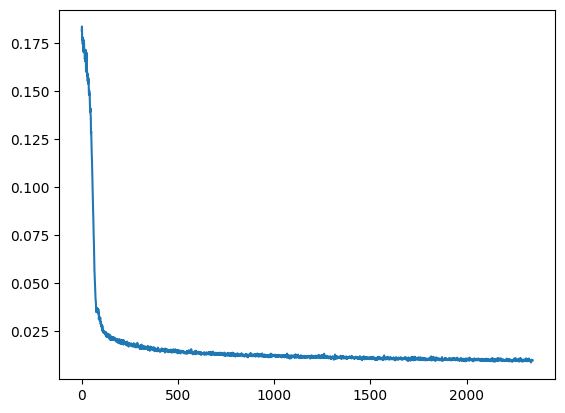

In [14]:
train_autoencoder(autoencoder, optimizer, trainloader)

> 테스트 이미지에 대해 학습한 Denoising Auto-Encoder가 잘 작동하는지 확인한다.

In [15]:
def test_autoencoder(net, testloader, n=10):
  net.eval()

  input_imgs = []
  recon_imgs = []

  with torch.no_grad():
    for i, (inputs, _) in enumerate(testloader):
      inputs = inputs.to(device)

      inputs_noise = torch.clip(inputs + torch.normal(mean=0, std=0.2, size=inputs.shape).to(device), min=0.0, max=1.0) # noise 추가

      outputs = net(inputs_noise)

      input_imgs.append(inputs_noise.detach().cpu().numpy())
      recon_imgs.append(outputs.detach().cpu().numpy())

      # 결과 확인을 위해 이미지 10개만 재생성
      if i == n:
        break


  # Auto-encoder를 이용하여 재생성한 이미지를 시각화
  plt.figure(figsize=(2*n, 4))
  for i in range(n):
    # original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(input_imgs[i].squeeze())
    plt.title("original")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(recon_imgs[i].squeeze())
    plt.title("reconstructed")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
  plt.show()
  plt.close()

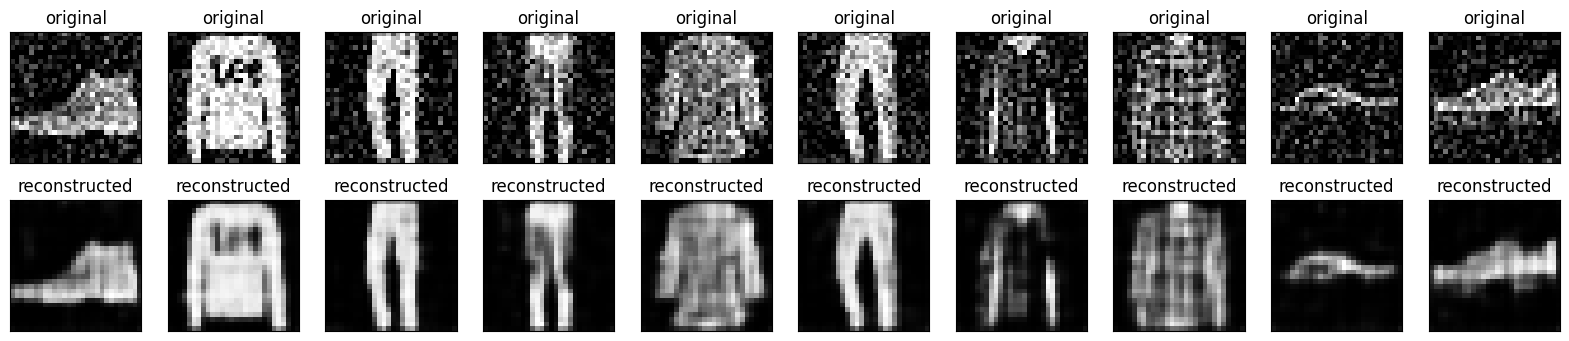

In [16]:
test_autoencoder(autoencoder, testloader)

## 4. Anomaly Detection

> 이번에는 이상 탐지 (Anomaly Detection)에 태스크에 대해 알아보도록 하자.
>
>Anomaly Detection이란, 정상 (Normal) 샘플과 비정상 (Abnormal) 샘플을 구별해내는 문제를 의미하며, 제조업 뿐만 아니라 CCTV, 의료 영상, Social Network 등 다양한 분야에서 응용이 되고 있다.
>


In [17]:
# Hyper-parameters
device = 'cuda' if torch.cuda.is_available() else 'cpu' # pytorch 0.4.0 이상 버젼에서 gpu 설정하는 방식, tensor.to(device) 이런식으로 사용
lr = 0.1
batch_size = 512

> Anomaly Detection을 위해 정상/비정상의 심장박동 데이터를 수집해놓은 ECG 데이터셋을 활용하고자 한다. ECG 데이터셋은 140개의 값이 있으며, 심장 박동이 정상이면 `1`, 비정상이면 `0`으로 라벨링되어 있다.
>
> 학습 데이터에 정상과 비정상에 대한 라벨 정보가 있어, 분류 문제로도 모델을 학습시킬 수 있지만, 여기서는 라벨을 사용하지 않고 Auto-Encoder 학습을 통한 Anomaly Detection을 하고자 한다.
>
>정상 데이터에서 오토인코더를 우선 학습시킨 후, 테스트 이미지를 잘 재생성 할 경우 정상 데이터로, 그렇지 못할 경우 비정상 데이터로 구분한다.

In [18]:
# Download the dataset
dataframe = pd.read_csv('http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv', header=None)
raw_data = dataframe.values
dataframe.head()

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,1.0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0


> ECG 데이터셋을 위한 Dataset과 DataLoader를 구현한다.

In [19]:
class ECG_dataset(torch.utils.data.Dataset):
    """
    ECG 데이터를 PyTorch에서 사용할 수 있도록 구성한 Custom Dataset

    raw_data의 마지막 열을 label로 사용하고,
    나머지 열을 ECG 입력 데이터로 사용

    전체 데이터를 Train 80% / Test 20%로 분할한 뒤,
    train 인자에 따라 Train 또는 Test 데이터를 반환
    """

    def __init__(self, raw_data, train=True):

        # raw_data의 마지막 열을 정답(label)으로 분리
        # labels의 shape: [전체 sample 수]
        labels = raw_data[:, -1]

        # 마지막 열을 제외한 나머지 열을 ECG 입력 데이터로 사용
        # data의 shape: [전체 sample 수, feature 수]
        data = raw_data[:, 0:-1]

        # 전체 데이터를 Train 80% / Test 20%로 분할
        #
        # random_state=21로 설정하여
        # 실행할 때마다 동일한 방식으로 데이터가 분할되도록 함
        train_data, test_data, train_labels, test_labels = train_test_split(
            data,
            labels,
            test_size=0.2,
            random_state=21
        )

        # train=True이면 Train Dataset을 사용
        if train:
            self.data = train_data
            self.labels = train_labels

        # train=False이면 Test Dataset을 사용
        else:
            self.data = test_data
            self.labels = test_labels


    def __getitem__(self, idx):

        # idx번째 ECG 데이터를 NumPy 배열에서
        # PyTorch FloatTensor로 변환
        #
        # data의 shape: [feature 수]
        data = torch.from_numpy(
            self.data[idx]
        ).type(torch.FloatTensor)

        # idx번째 label을 PyTorch FloatTensor로 변환
        #
        # scalar label을 [label] 형태의 NumPy 배열로 만든 후 Tensor로 변환
        # 따라서 labels의 shape: [1]
        labels = torch.from_numpy(
            np.array([self.labels[idx]])
        ).type(torch.FloatTensor)

        # 하나의 ECG 데이터와 이에 대응하는 label 반환
        return (data, labels)


    def __len__(self):

        # 현재 Dataset에 포함된 전체 sample 수 반환
        return len(self.data)

In [20]:
trainset = ECG_dataset(raw_data, train=True)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0)

testset = ECG_dataset(raw_data, train=False)
testloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=False, num_workers=0)

print(len(trainset))
print(len(testset))

3998
1000


> Anomaly Detection을 위한 Auto-Encoder를 구현한다.

In [21]:
class AnomalyDetector(nn.Module):
  def __init__(self):
    super(AnomalyDetector, self).__init__()
    self.encoder = nn.Sequential(
        nn.Linear(140, 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, 8),
        nn.ReLU(),
    )
    self.decoder = nn.Sequential(
        nn.Linear(8, 16),
        nn.ReLU(),
        nn.Linear(16, 32),
        nn.ReLU(),
        nn.Linear(32, 140),
        nn.Sigmoid()
    )

  def forward(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

In [22]:
autoencoder = AnomalyDetector().to(device)

> 위에서 학습한 방식과 마찬가지로 Auto-Encoder를 학습한다.

In [23]:
criterion = nn.L1Loss()
optimizer = optim.Adam(autoencoder.parameters(), lr=lr)

def train_autoencoder(net, optimizer, trainloader, epochs=20):

  loss_list = []
  steps = []
  step = 0
  for epoch in range(epochs):

    running_loss = 0.0
    for i, data in enumerate(trainloader):
      inputs, _ = data
      inputs = inputs.to(device)

      optimizer.zero_grad()
      outputs = net(inputs)
      loss = criterion(outputs, inputs)
      loss.backward()
      optimizer.step()

      running_loss += loss.item()
      loss_list.append(loss.item())
      steps.append(step)
      step += 1
      if (i+1) % 5 == 0:
          print('[%d, %5d] loss: %.3f' %
                (epoch + 1, i + 1, running_loss / 100))
          running_loss = 0.0

  plt.plot(steps, loss_list)
  print('Finished Training')

[1,     5] loss: 0.032
[2,     5] loss: 0.027
[3,     5] loss: 0.027
[4,     5] loss: 0.027
[5,     5] loss: 0.027
[6,     5] loss: 0.027
[7,     5] loss: 0.027
[8,     5] loss: 0.027
[9,     5] loss: 0.027
[10,     5] loss: 0.027
[11,     5] loss: 0.027
[12,     5] loss: 0.027
[13,     5] loss: 0.027
[14,     5] loss: 0.027
[15,     5] loss: 0.027
[16,     5] loss: 0.027
[17,     5] loss: 0.027
[18,     5] loss: 0.027
[19,     5] loss: 0.027
[20,     5] loss: 0.027
Finished Training


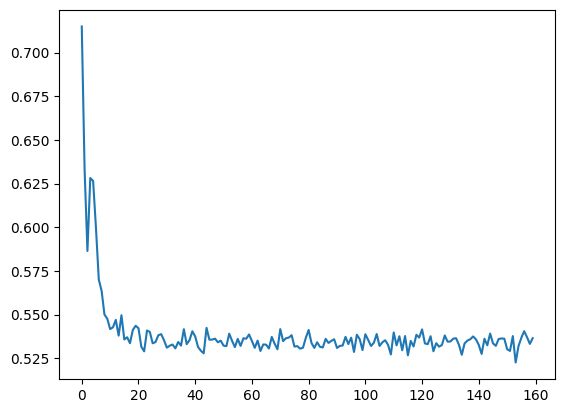

In [24]:
train_autoencoder(autoencoder, optimizer, trainloader)

> 학습한 Auto-Encoder를 학습 데이터에 대해 적용하여 Reconstruction Error를 측정하고, 이를 이용하여 정상인지 비정상인지 구분할 Threshold를 결정한다.

In [25]:
def choose_threshold(net, trainloader):
    """
    학습 데이터의 Reconstruction Error 분포를 이용하여
    이상 탐지(Anomaly Detection)에 사용할 Threshold를 결정하는 함수

    Autoencoder가 정상 데이터에 대해서는 작은 Reconstruction Error를
    가진다는 가정을 이용하여 Threshold를 설정
    """

    # 모델을 Evaluation Mode로 변경
    # Dropout, BatchNorm 등이 학습 모드와 다르게 동작하도록 설정
    net.eval()

    # 각 batch의 Reconstruction Error를 저장할 리스트
    train_loss = []

    # Threshold 계산 과정에서는 모델을 학습하지 않으므로
    # gradient 계산을 비활성화하여 메모리 사용량과 연산량을 줄임
    with torch.no_grad():

        for i, data in enumerate(trainloader):

            # ECG 입력 데이터와 label을 가져옴
            # Autoencoder의 Reconstruction Error만 필요하므로
            # label은 사용하지 않음
            inputs, _ = data

            # 입력 데이터를 연산에 사용할 device로 이동
            inputs = inputs.to(device)

            # Autoencoder에 정상 학습 데이터를 입력하여 복원
            outputs = net(inputs)

            # 원본 입력 inputs와 복원 결과 outputs 사이의
            # Reconstruction Error 계산
            #
            # 정상 데이터는 Autoencoder가 잘 복원할 수 있으므로
            # 일반적으로 Reconstruction Error가 작을 것으로 기대
            loss = criterion(outputs, inputs)

            # 계산된 Reconstruction Error를
            # CPU의 NumPy 값으로 변환하여 저장
            train_loss.append(
                loss.detach().cpu().numpy()
            )

    # Reconstruction Error 리스트를 NumPy 배열로 변환
    train_loss = np.array(train_loss)

    # 학습 데이터의 Reconstruction Error 분포를 Histogram으로 시각화
    plt.hist(train_loss, bins=50)
    plt.xlabel("Reconstruction error")
    plt.ylabel("No of examples")
    plt.show()

    # 이상 데이터를 판별하기 위한 Threshold 설정
    #
    # Threshold = Reconstruction Error의 평균 + 표준편차
    #
    # 이후 Reconstruction Error가 Threshold보다 크면
    # 정상 데이터와 비교했을 때 복원이 잘 되지 않은 데이터로 보고
    # 이상(Anomaly)으로 판정할 수 있음
    threshold = np.mean(train_loss) + np.std(train_loss)

    print("Threshold: ", threshold)

    return threshold

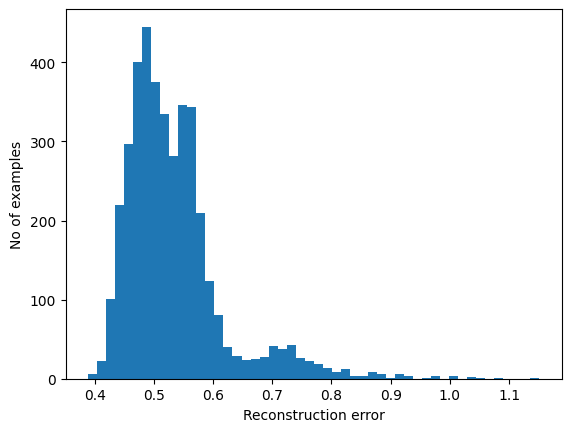

Threshold:  0.6192287


In [26]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=1, shuffle=False, num_workers=0)

threshold = choose_threshold(autoencoder, trainloader)

> 학습 데이터를 이용하여 결정한 Threshold 값을 이용하여, 테스트 데이터의 Reconstruction Error를 측정하여 정상 / 비정상 여부를 판단한다.

In [27]:
def detect_anomaly(net, threshold, testloader):
    """
    학습 데이터로부터 결정한 Threshold를 이용하여
    Test 데이터가 정상인지 이상인지 판별하고 성능을 평가하는 함수
    """

    # 모델을 Evaluation Mode로 변경
    net.eval()

    # Test 데이터의 Reconstruction Error,
    # 실제 Label, 예측 Label을 저장할 리스트
    test_loss = []
    label_list = []
    pred_list = []

    # 모델의 파라미터를 업데이트하지 않으므로
    # gradient 계산을 비활성화
    with torch.no_grad():

        for i, data in enumerate(testloader):

            # Test 데이터와 실제 Label을 가져옴
            inputs, labels = data

            # 입력 데이터를 연산에 사용할 device로 이동
            inputs = inputs.to(device)

            # Autoencoder를 통해 입력 데이터를 복원
            outputs = net(inputs)

            # 원본 입력과 복원된 출력 사이의
            # Reconstruction Error 계산
            loss = criterion(outputs, inputs)

            # Reconstruction Error를 Threshold와 비교하여 정상/이상 판별
            #
            # loss <= threshold → 1
            # loss > threshold  → 0
            #
            # 즉, Reconstruction Error가 작으면 정상(1),
            # 크면 이상(0)으로 판정
            preds = int(loss <= threshold)

            # Reconstruction Error를 CPU의 NumPy 값으로 변환하여 저장
            test_loss.append(
                loss.detach().cpu().numpy()
            )

            # 실제 Label 저장
            label_list.append(
                labels.detach().cpu().numpy()
            )

            # 예측 Label 저장
            pred_list.append(preds)

    # Reconstruction Error를 NumPy 배열로 변환
    test_loss = np.array(test_loss)

    # Test 데이터의 Reconstruction Error 분포를 Histogram으로 시각화
    plt.hist(test_loss, bins=50)
    plt.xlabel("Reconstruction error-test")
    plt.ylabel("No of examples")
    plt.show()

    # 성능 평가를 위해 실제 Label과 예측 Label을
    # 1차원 NumPy 배열로 변환
    label_list = np.array(label_list).squeeze()
    pred_list = np.array(pred_list).squeeze()

    # 실제 Label과 예측 Label을 비교하여
    # Accuracy, Precision, Recall 계산
    print("Accuracy = {}".format(
        accuracy_score(label_list, pred_list)
    ))

    print("Precision = {}".format(
        precision_score(label_list, pred_list)
    ))

    print("Recall = {}".format(
        recall_score(label_list, pred_list)
    ))

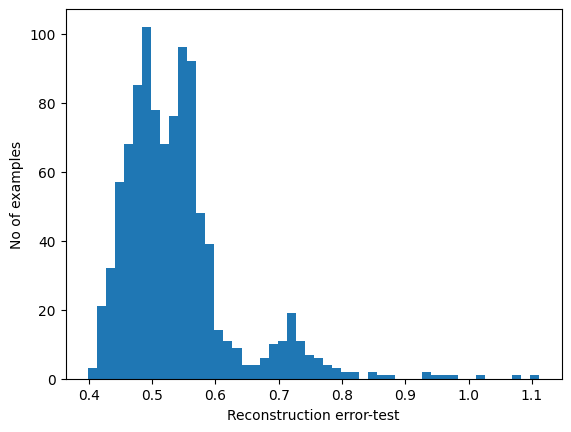

Accuracy = 0.598
Precision = 0.5891647855530474
Recall = 0.9321428571428572


In [28]:
testloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=False, num_workers=0)

detect_anomaly(autoencoder, threshold, testloader)